# Demo 8— Image Generation using Generative Adversarial Networks (GAN)

### **Problem Definition**
The goal of this demo is to generate new handwritten digits that look realistic.  
Unlike classification tasks that rely on labelled data, this is an **unsupervised learning** problem — the model learns the data distribution directly from the images.  
We use the **MNIST dataset** of 28 × 28 grayscale digits and train a generative model to produce similar images from random noise.

---

### **Chosen AI Technique — Generative Adversarial Network (GAN)**
A GAN consists of two neural networks trained simultaneously in a competitive setting:
- **Generator (G):** learns to map random noise → synthetic images.
- **Discriminator (D):** learns to distinguish real images from fake ones.

During training,  
- the **Discriminator** minimises its classification error,  
- the **Generator** tries to fool the Discriminator,  
forming a *min–max* adversarial process.  
Equilibrium is reached when the Discriminator can no longer tell real from fake (≈ 50 % accuracy).

---

### **Dataset and Pre-processing**
- Dataset: **MNIST** (60 000 train / 10 000 test images).  
- Each image: 28×28 grayscale (1 channel).  
- Normalised to range [ −1, 1 ] for stable GAN training.  
- Data loaded and shuffled in mini-batches using `DataLoader`.

---

### Link to notebook: https://colab.research.google.com/drive/13GeN5R2ztx32_DF8mWBBZo67GOQrNfwf?usp=sharing

In [9]:
# Import necessary libraries
import torch
from torch import nn

import math
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
import numpy as np
from torchsummary import summary

import torch.nn.functional as F

## Problem Definition

This demo focuses on **image generation using Generative Adversarial Networks (GANs)**.  
The goal is to train a model capable of generating **new handwritten digit images** that resemble those in the **MNIST dataset**.  

GANs learn to model complex data distributions by setting up a **competition between two neural networks** — a **Generator** that creates fake images, and a **Discriminator** that tries to tell fake from real.  
Through this adversarial training process, the Generator becomes increasingly skilled at producing realistic images, effectively capturing the underlying distribution of handwritten digits.

In [10]:
torch.manual_seed(111)

In [11]:
device = ""
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

## Dataset and Preprocessing

The **MNIST dataset** is used for this task, containing **60,000 training images** and **10,000 test images** of handwritten digits from 0 to 9.  
Each image is grayscale with a size of **28×28 pixels**, flattened into 784 features for the neural network input.

To stabilize and accelerate training, images are **normalized** to the range [-1, 1] and converted into tensors.  
The dataset is loaded using PyTorch’s `DataLoader` in batches of 32, ensuring efficient GPU utilization and random shuffling for improved generalization.

In [12]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)

In [13]:
train_set = torchvision.datasets.MNIST(
    root=".", train=True, download=True, transform=transform
)

In [14]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

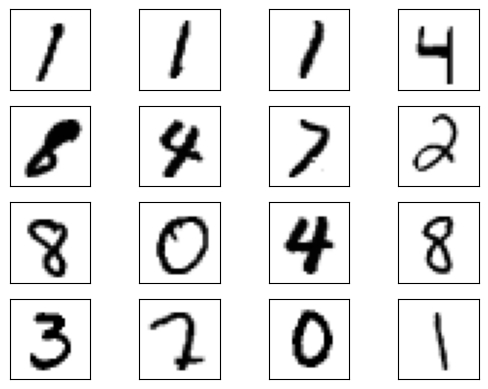

In [15]:
real_samples, mnist_labels = next(iter(train_loader))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
    plt.xticks([])
    plt.yticks([])

## Model Architecture

GANs consist of two key components trained simultaneously:

- **Generator (G):**  
  Takes random noise as input and transforms it through a series of linear and ReLU layers into a **synthetic 28×28 image**.  
  The final activation function, **Tanh**, outputs pixel values between -1 and 1 to match the normalized real data distribution.

- **Discriminator (D):**  
  A deep feedforward network that receives either real or generated images.  
  It applies multiple fully connected layers with **ReLU activations** and **Dropout** for regularization.  
  The final **Sigmoid layer** outputs a probability indicating how “real” an image is.

During training, **G tries to fool D**, while **D tries to distinguish real from fake**, resulting in a powerful adversarial learning dynamic.

In [16]:
class Discriminator(nn.Module):  # Define the architecture for both the generator and discriminator models.
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        output = self.model(x)
        return output

discriminator = Discriminator().to(device=device)
summary(discriminator, input_size=(784,1), batch_size = 2*batch_size)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        output = output.view(x.size(0), 1, 28, 28)
        return output

generator = Generator().to(device=device)
summary(generator, input_size=(1,100), batch_size=batch_size)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [64, 1024]         803,840
              ReLU-2                 [64, 1024]               0
           Dropout-3                 [64, 1024]               0
            Linear-4                  [64, 512]         524,800
              ReLU-5                  [64, 512]               0
           Dropout-6                  [64, 512]               0
            Linear-7                  [64, 256]         131,328
              ReLU-8                  [64, 256]               0
           Dropout-9                  [64, 256]               0
           Linear-10                    [64, 1]             257
          Sigmoid-11                    [64, 1]               0
Total params: 1,460,225
Trainable params: 1,460,225
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.19
Forw

## Training Process

Training alternates between **updating the Discriminator** and **updating the Generator**:

1. **Discriminator Step:**
   - Real images are labeled as 1, fake ones as 0.  
   - The Discriminator is trained to minimize **binary cross-entropy loss**, improving its ability to detect generated images.

2. **Generator Step:**
   - The Generator creates fake images from random noise.  
   - Its loss is computed based on how well it fools the Discriminator into classifying fakes as real (label 1).

The learning rate is set to **0.0001** with **Adam optimizers** for both networks.  
This adversarial feedback loop continues for **30 epochs**, gradually improving image quality as the losses stabilize.

In [17]:
lr = 0.0001
num_epochs = 30
loss_function = nn.BCELoss()

optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

# The training may take a long time on cpu, so you probably need to run this after class when gpu is unavailable.

# Initialize lists to store the losses
d_losses = []
g_losses = []

for epoch in range(num_epochs):
    for n, (real_samples, mnist_labels) in enumerate(train_loader):
        # Data for training the discriminator
        real_samples = real_samples.to(device=device)
        real_samples_labels = torch.ones((batch_size, 1)).to(
            device=device
        )
        latent_space_samples = torch.randn((batch_size, 100)).to(
            device=device
        )
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1)).to(
            device=device
        )
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat(
            (real_samples_labels, generated_samples_labels)
        )

        # Training the discriminator
        discriminator.zero_grad()
        output_discriminator = discriminator(all_samples)
        loss_discriminator = loss_function(
            output_discriminator, all_samples_labels
        )
        loss_discriminator.backward()
        optimizer_discriminator.step()

        # Data for training the generator
        latent_space_samples = torch.randn((batch_size, 100)).to(
            device=device
        )

        # Training the generator
        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        output_discriminator_generated = discriminator(generated_samples)
        loss_generator = loss_function(
            output_discriminator_generated, real_samples_labels
        )
        loss_generator.backward()
        optimizer_generator.step()

        # Track the losses
        d_losses.append(loss_discriminator.item())
        g_losses.append(loss_generator.item())

        # Show loss
        if n == batch_size - 1:
            print(f"Epoch: {epoch} Loss D.: {loss_discriminator},Epoch: {epoch} Loss G.: {loss_generator}")
            # print(f"Epoch: {epoch} Loss G.: {loss_generator}")

Epoch: 0 Loss D.: 0.5704400539398193,Epoch: 0 Loss G.: 0.47998619079589844
Epoch: 1 Loss D.: 0.033863067626953125,Epoch: 1 Loss G.: 4.480073928833008
Epoch: 2 Loss D.: 0.012867506593465805,Epoch: 2 Loss G.: 5.818132400512695
Epoch: 3 Loss D.: 0.018647316843271255,Epoch: 3 Loss G.: 13.54281997680664
Epoch: 4 Loss D.: 0.08987952768802643,Epoch: 4 Loss G.: 4.152669906616211
Epoch: 5 Loss D.: 0.033021025359630585,Epoch: 5 Loss G.: 3.666787624359131
Epoch: 6 Loss D.: 0.058926187455654144,Epoch: 6 Loss G.: 3.0371646881103516
Epoch: 7 Loss D.: 0.29114729166030884,Epoch: 7 Loss G.: 2.9075980186462402
Epoch: 8 Loss D.: 0.19518806040287018,Epoch: 8 Loss G.: 2.748884677886963
Epoch: 9 Loss D.: 0.22792300581932068,Epoch: 9 Loss G.: 2.0101473331451416
Epoch: 10 Loss D.: 0.4022052586078644,Epoch: 10 Loss G.: 1.6666688919067383
Epoch: 11 Loss D.: 0.35622188448905945,Epoch: 11 Loss G.: 1.7345492839813232
Epoch: 12 Loss D.: 0.4506022334098816,Epoch: 12 Loss G.: 1.488746166229248
Epoch: 13 Loss D.: 0.43

## Results and Analysis

The following plot shows how **Generator and Discriminator losses evolve** during training:  
- Early epochs show strong oscillations, typical of GAN training dynamics.  
- Over time, both losses converge, indicating a balance between Generator and Discriminator performance.

After training, the Generator produces **synthetic MNIST-like digits** from random noise vectors.  
Visually, many generated images resemble authentic digits, demonstrating that the model has effectively captured the MNIST distribution.  

This result highlights the **power of GANs to learn unsupervised representations** and synthesize new data similar to the training set.

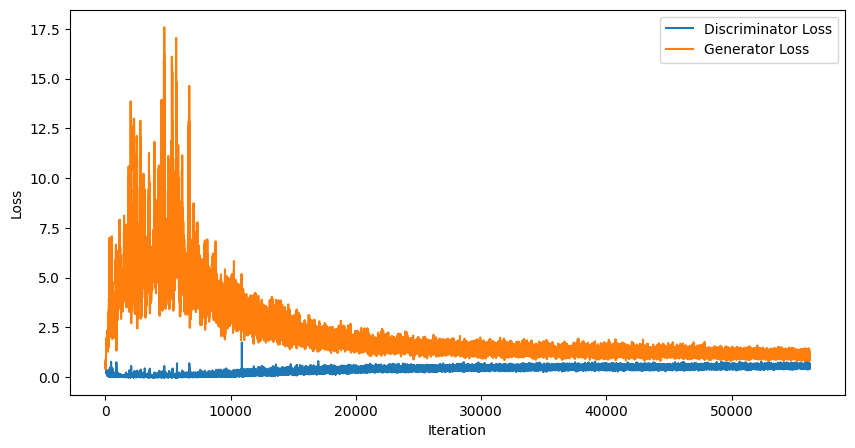

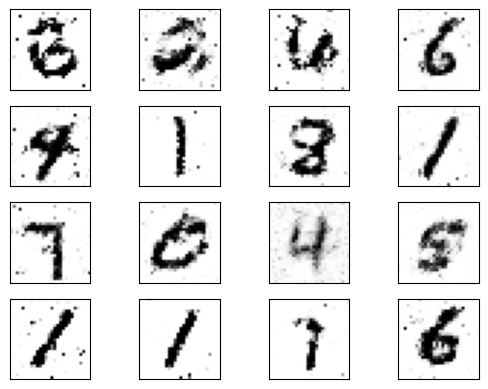

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()

latent_space_samples = torch.randn(batch_size, 100).to(device=device)
generated_samples = generator(latent_space_samples)

generated_samples = generated_samples.cpu().detach()
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(generated_samples[i].reshape(28, 28), cmap="gray_r")
    plt.xticks([])
    plt.yticks([])

## Conclusion

In this demo, a **Generative Adversarial Network (GAN)** was implemented from scratch using PyTorch to generate realistic handwritten digits.  
Through adversarial training between the Generator and Discriminator, the model learned to mimic the MNIST data distribution effectively.

This experiment demonstrates the **core principle of generative modeling** — using competition between two networks to achieve increasingly realistic synthetic data.  
Future improvements could include **deep convolutional GANs (DCGANs)** or **conditional GANs (cGANs)** for more complex, controllable image generation.